In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
# Load the diabetes dataset
df = pd.read_csv("data/diabetes.csv")

# Display the first 5 rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Check the number of rows and columns
print("Dataset Shape:")
print(df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display dataset information
print("\nDataset Information:")
df.info()

Dataset Shape:
(768, 9)

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# Check the number of diabetic and non-diabetic patients
print("Outcome Distribution:")
print(df["Outcome"].value_counts())

# Calculate percentage distribution
print("\nOutcome Percentage:")
print(df["Outcome"].value_counts(normalize=True) * 100)

Outcome Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome Percentage:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [6]:
# Columns where zero represents a missing value
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Zero values in important columns:")
print((df[zero_columns] == 0).sum())

Zero values in important columns:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [7]:
# Replace medically invalid zero values with NaN
df_clean = df.copy()

df_clean[zero_columns] = df_clean[zero_columns].replace(0, np.nan)

print("Missing values after replacing zeros:")
print(df_clean.isnull().sum())

Missing values after replacing zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [8]:
# Fill missing values using the median of each column
for column in zero_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

print("Missing values after imputation:")
print(df_clean.isnull().sum())

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [9]:
# Input features
X = df_clean.drop("Outcome", axis=1)

# Target variable
y = df_clean["Outcome"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (768, 8)
Target Shape: (768,)


In [10]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 614
Testing samples: 154


In [11]:
# Standardize the feature values
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Feature scaling completed!
Training data shape: (614, 8)
Testing data shape: (154, 8)


In [12]:
# Train K-Nearest Neighbors model
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


In [13]:
# Make predictions using KNN
knn_predictions = knn_model.predict(X_test_scaled)

# Calculate evaluation metrics
knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_precision = precision_score(y_test, knn_predictions)
knn_recall = recall_score(y_test, knn_predictions)
knn_f1 = f1_score(y_test, knn_predictions)

print("KNN Model Performance")
print("---------------------")
print("Accuracy:", round(knn_accuracy, 4))
print("Precision:", round(knn_precision, 4))
print("Recall:", round(knn_recall, 4))
print("F1 Score:", round(knn_f1, 4))

KNN Model Performance
---------------------
Accuracy: 0.7532
Precision: 0.66
Recall: 0.6111
F1 Score: 0.6346


In [14]:
# Train Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [15]:
# Make predictions using Logistic Regression
logistic_predictions = logistic_model.predict(X_test_scaled)

# Calculate evaluation metrics
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)

print("Logistic Regression Performance")
print("-------------------------------")
print("Accuracy:", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall:", round(logistic_recall, 4))
print("F1 Score:", round(logistic_f1, 4))

Logistic Regression Performance
-------------------------------
Accuracy: 0.7078
Precision: 0.6
Recall: 0.5
F1 Score: 0.5455


In [16]:
# Train Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [17]:
# Make predictions using Decision Tree
decision_tree_predictions = decision_tree_model.predict(X_test)

# Calculate evaluation metrics
decision_tree_accuracy = accuracy_score(
    y_test, decision_tree_predictions
)

decision_tree_precision = precision_score(
    y_test, decision_tree_predictions
)

decision_tree_recall = recall_score(
    y_test, decision_tree_predictions
)

decision_tree_f1 = f1_score(
    y_test, decision_tree_predictions
)

print("Decision Tree Performance")
print("-------------------------")
print("Accuracy:", round(decision_tree_accuracy, 4))
print("Precision:", round(decision_tree_precision, 4))
print("Recall:", round(decision_tree_recall, 4))
print("F1 Score:", round(decision_tree_f1, 4))

Decision Tree Performance
-------------------------
Accuracy: 0.6818
Precision: 0.5532
Recall: 0.4815
F1 Score: 0.5149


In [18]:
# Create a comparison table

comparison = pd.DataFrame({
    "Model": [
        "KNN",
        "Logistic Regression",
        "Decision Tree"
    ],
    
    "Accuracy": [
        knn_accuracy,
        logistic_accuracy,
        decision_tree_accuracy
    ],
    
    "Precision": [
        knn_precision,
        logistic_precision,
        decision_tree_precision
    ],
    
    "Recall": [
        knn_recall,
        logistic_recall,
        decision_tree_recall
    ],
    
    "F1 Score": [
        knn_f1,
        logistic_f1,
        decision_tree_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.753247,0.660000,0.611111,0.634615
1,Logistic Regression,0.707792,0.600000,0.500000,0.545455
2,Decision Tree,0.681818,0.553191,0.481481,0.514851


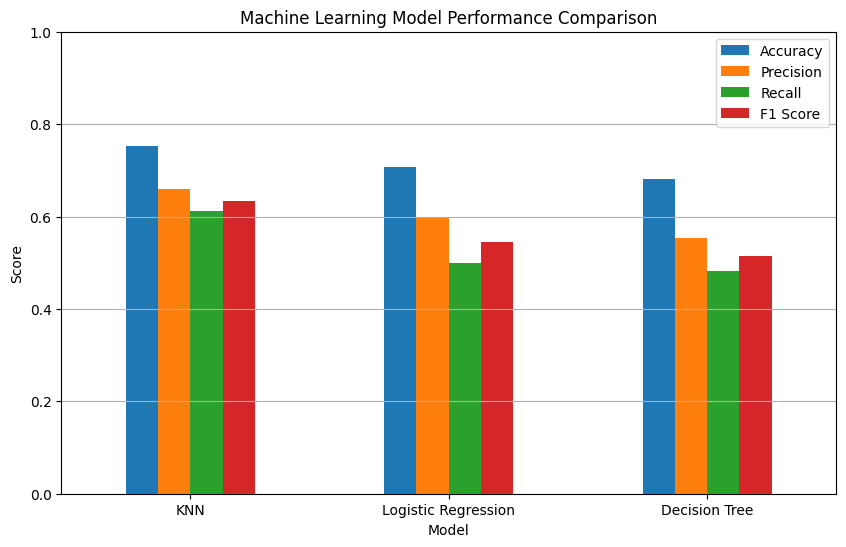

In [19]:
# Create model performance comparison graph

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

In [20]:
# Confusion Matrix for KNN
print("KNN Confusion Matrix")
print(confusion_matrix(y_test, knn_predictions))

print("\nLogistic Regression Confusion Matrix")
print(confusion_matrix(y_test, logistic_predictions))

print("\nDecision Tree Confusion Matrix")
print(confusion_matrix(y_test, decision_tree_predictions))

KNN Confusion Matrix
[[83 17]
 [21 33]]

Logistic Regression Confusion Matrix
[[82 18]
 [27 27]]

Decision Tree Confusion Matrix
[[79 21]
 [28 26]]


In [21]:
# Select the model with the highest Recall

model_results = {
    "KNN": {
        "model": knn_model,
        "recall": knn_recall,
        "f1": knn_f1
    },
    
    "Logistic Regression": {
        "model": logistic_model,
        "recall": logistic_recall,
        "f1": logistic_f1
    },
    
    "Decision Tree": {
        "model": decision_tree_model,
        "recall": decision_tree_recall,
        "f1": decision_tree_f1
    }
}

best_model_name = max(
    model_results,
    key=lambda x: (
        model_results[x]["recall"],
        model_results[x]["f1"]
    )
)

best_model = model_results[
    best_model_name
]["model"]

print("Best Model Selected:", best_model_name)
print(
    "Reason: Highest Recall is prioritized to reduce "
    "the chance of missing diabetic patients."
)

Best Model Selected: KNN
Reason: Highest Recall is prioritized to reduce the chance of missing diabetic patients.


c:\Users\Arjun\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


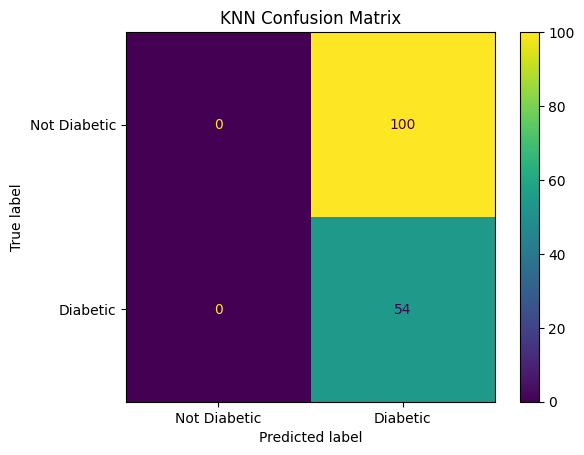

In [22]:
# Confusion Matrix for KNN

from sklearn.metrics import ConfusionMatrixDisplay

# Predict using the KNN model
knn_predictions = knn_model.predict(X_test)

# Create and display confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_predictions,
    display_labels=["Not Diabetic", "Diabetic"]
)

plt.title("KNN Confusion Matrix")
plt.show()

In [23]:
# Business-based model selection

print("Business Criteria:")
print("The clinic wants to detect as many real diabetic patients as possible.")
print("Therefore, Recall is an important metric because missing a diabetic patient is risky.")

print("\nModel Comparison:")
print(comparison_df)

best_model = comparison_df.loc[
    comparison_df["Recall"].idxmax()
]

print("\nBest Model Based on Recall:")
print(best_model)

Business Criteria:
The clinic wants to detect as many real diabetic patients as possible.
Therefore, Recall is an important metric because missing a diabetic patient is risky.

Model Comparison:


NameError: name 'comparison_df' is not defined

In [24]:
comparison_df = pd.DataFrame({
    "Model": ["KNN", "Logistic Regression", "Decision Tree"],
    "Accuracy": [
        knn_accuracy,
        logistic_accuracy,
        decision_tree_accuracy
    ],
    "Precision": [
        knn_precision,
        logistic_precision,
        decision_tree_precision
    ],
    "Recall": [
        knn_recall,
        logistic_recall,
        decision_tree_recall
    ],
    "F1 Score": [
        knn_f1,
        logistic_f1,
        decision_tree_f1
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.753247,0.660000,0.611111,0.634615
1,Logistic Regression,0.707792,0.600000,0.500000,0.545455
2,Decision Tree,0.681818,0.553191,0.481481,0.514851


In [25]:
print("Business Criteria:")
print("The clinic wants to detect as many real diabetic patients as possible.")
print("Therefore, Recall is an important metric because missing a diabetic patient is risky.")

print("\nModel Comparison:")
print(comparison_df)

best_model = comparison_df.loc[
    comparison_df["Recall"].idxmax()
]

print("\nBest Model Based on Recall:")
print(best_model)

Business Criteria:
The clinic wants to detect as many real diabetic patients as possible.
Therefore, Recall is an important metric because missing a diabetic patient is risky.

Model Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score
0                  KNN  0.753247   0.660000  0.611111  0.634615
1  Logistic Regression  0.707792   0.600000  0.500000  0.545455
2        Decision Tree  0.681818   0.553191  0.481481  0.514851

Best Model Based on Recall:
Model             KNN
Accuracy     0.753247
Precision        0.66
Recall       0.611111
F1 Score     0.634615
Name: 0, dtype: object


In [26]:
import joblib
import os

# Create saved_models folder if it does not exist
os.makedirs("saved_models", exist_ok=True)

# Save the trained KNN model
joblib.dump(knn_model, "saved_models/diabetes_model.pkl")

# Save the scaler
joblib.dump(scaler, "saved_models/scaler.pkl")

print("KNN model saved successfully!")
print("Scaler saved successfully!")

KNN model saved successfully!
Scaler saved successfully!
